In [4]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

# ICD §5.1: Packet Size = 950 bytes, Little Endian
# ICD Table 10 header layout (44 bytes total before ADC data):
#   [0:4]   Start ID "ASIO"
#   [4]     Relay Configuration (1 byte)
#   [5:15]  Temperature Data (10 bytes = 5 sensors × 2 bytes each, 16-bit LE)
#   [15]    Bad Command Count (1 byte)
#   [16]    Padded Zero (1 byte)
#   [17:19] Voltage data (2 bytes, 16-bit LE)
#   [19:21] Current data (2 bytes, 16-bit LE)
#   [21:23] Packet Count (2 bytes, 16-bit LE)
#   [23]    Command Count (1 byte)
#   [24:30] MUSE Time (6 bytes: 4 seconds + 2 sub-seconds, LE)
#   [30:32] Padded Zeros (2 bytes)
#   [32:36] ASIO Time ms (4 bytes, 32-bit LE)
#   [36:40] First Data Point ASIO Time ms (4 bytes, 32-bit LE)
#   [40:44] Padded Zeros (4 bytes)
#   [44:944] ADC Data (900 bytes = 50 segments × 18 bytes)
#   [944:948] End ID "STOP"
#   [948:950] CRC (2 bytes)

PACKET_SIZE       = 950
HEADER_SIZE       = 44
ADC_SEGMENT_BYTES = 18   # 6 channels × 3 bytes each
N_SEGMENTS        = 50   # per packet
ADC_DATA_SIZE     = N_SEGMENTS * ADC_SEGMENT_BYTES  # 900 bytes
STOP_OFFSET       = HEADER_SIZE + ADC_DATA_SIZE     # 944

rawdata = np.fromfile(
    "/Users/evanwilliams/Desktop/Research/EM Testing/testing-results/Data/FlipSample/20260602.0x02B4",
    dtype=np.uint8,
)


def find(targetString, data):
    targetBytes = targetString.encode()
    targetIntegers = np.frombuffer(targetBytes, dtype=np.uint8)
    windows = sliding_window_view(data, len(targetIntegers))
    matches = (windows == targetIntegers).all(axis=1)
    return np.where(matches)[0]


def decode16le(b2):
    """2 bytes → unsigned 16-bit little-endian integer."""
    return int(b2[0]) | (int(b2[1]) << 8)


def decode24le(b3):
    """3 bytes → unsigned 24-bit little-endian integer (ICD §5.1.3, Table 13)."""
    return int(b3[0]) | (int(b3[1]) << 8) | (int(b3[2]) << 16)


def decode32le(b4):
    """4 bytes → unsigned 32-bit little-endian integer."""
    return int(b4[0]) | (int(b4[1]) << 8) | (int(b4[2]) << 16) | (int(b4[3]) << 24)


# ----- Build packet list using fixed offsets (ICD §5.1.2: 950-byte fixed packet) -----
# Searching for STOP at asioIndex + STOP_OFFSET is far more robust than pairing
# find("STOP") results, which breaks if "STOP" appears by coincidence inside ADC data.
asioMatches = find("ASIO", rawdata)

packetList = []
bad_packets = 0
for asioIndex in asioMatches:
    end = asioIndex + PACKET_SIZE
    if end > len(rawdata):
        bad_packets += 1
        continue
    stop_check = rawdata[asioIndex + STOP_OFFSET : asioIndex + STOP_OFFSET + 4].tobytes()
    if stop_check != b'STOP':
        bad_packets += 1
        continue
    packetList.append(rawdata[asioIndex:end])

print(f"Valid packets: {len(packetList)}  |  Rejected: {bad_packets}")


# ----- Extract relay config, flip events, and all header housekeeping fields -----
def parseHeader(packet):
    """Return a dict of all header fields for one packet."""
    relay = int(packet[4])

    temps_raw = [decode16le(packet[5 + i*2 : 7 + i*2]) for i in range(5)]
    bad_cmd_count = int(packet[15])
    voltage_raw   = decode16le(packet[17:19])
    current_raw   = decode16le(packet[19:21])
    packet_count  = decode16le(packet[21:23])
    cmd_count     = int(packet[23])

    # MUSE time: 4 bytes seconds + 2 bytes sub-seconds (LE, epoch = 1958-01-01)
    muse_sec    = decode32le(packet[24:28])
    muse_subsec = decode16le(packet[28:30])

    asio_time_ms        = decode32le(packet[32:36])
    first_dp_asio_ms    = decode32le(packet[36:40])

    return {
        'relay':          relay,
        'temps_raw':      temps_raw,
        'bad_cmd_count':  bad_cmd_count,
        'voltage_raw':    voltage_raw,
        'current_raw':    current_raw,
        'packet_count':   packet_count,
        'cmd_count':      cmd_count,
        'muse_sec':       muse_sec,
        'muse_subsec':    muse_subsec,
        'asio_time_ms':   asio_time_ms,
        'first_dp_ms':    first_dp_asio_ms,
    }


def getRelayConfig(packetList):
    relayConfigs = []
    hxr11States  = []
    flips        = []
    previousHXR11 = None

    for idx, packet in enumerate(packetList):
        relayByte = int(packet[4])
        relayConfigs.append(relayByte)

        # ICD Table 12: bit layout LSB→MSB = EUV5,EUV6,EUV7,HXR8,HXR9,HXR10,HXR11,Unused
        # HXR11 is bit 6
        hxr11State = bool((relayByte >> 6) & 0x01)
        hxr11States.append(hxr11State)

        if previousHXR11 is not None and hxr11State != previousHXR11:
            direction = "OFF->ON" if hxr11State else "ON->OFF"
            flips.append({'packet': idx, 'relay_byte': relayByte, 'direction': direction, 'state': hxr11State})

        previousHXR11 = hxr11State

    return relayConfigs, hxr11States, flips


# ----- Parse ADC data: each channel is 3 bytes decoded as a 24-bit LE integer -----
def getData(packetList):
    _, hxr11States, flips = getRelayConfig(packetList)
    print(f"hxr11States: {len(hxr11States)}  |  flips: {len(flips)}")

    SXR1, SXR2, SXR3, SXR4, HXR, EUV = [], [], [], [], [], []
    headers = []

    for packet in packetList:
        headers.append(parseHeader(packet))

        adc_bytes = packet[HEADER_SIZE : HEADER_SIZE + ADC_DATA_SIZE]
        if len(adc_bytes) != ADC_DATA_SIZE:
            raise ValueError(f"Unexpected ADC data length: {len(adc_bytes)}")

        # 50 segments of 18 bytes each; each channel = 3 bytes → 24-bit LE integer
        for seg_start in range(0, ADC_DATA_SIZE, ADC_SEGMENT_BYTES):
            seg = adc_bytes[seg_start : seg_start + ADC_SEGMENT_BYTES]
            SXR1.append(decode24le(seg[0:3]))
            SXR2.append(decode24le(seg[3:6]))
            SXR3.append(decode24le(seg[6:9]))
            SXR4.append(decode24le(seg[9:12]))
            HXR.append( decode24le(seg[12:15]))
            EUV.append( decode24le(seg[15:18]))

    return {
        'SXR1':        np.array(SXR1,  dtype=np.uint32),
        'SXR2':        np.array(SXR2,  dtype=np.uint32),
        'SXR3':        np.array(SXR3,  dtype=np.uint32),
        'SXR4':        np.array(SXR4,  dtype=np.uint32),
        'HXR':         np.array(HXR,   dtype=np.uint32),
        'EUV':         np.array(EUV,   dtype=np.uint32),
        'hxr11States': np.array(hxr11States, dtype=bool),
        'flips':       flips,
        'headers':     headers,
    }


data = getData(packetList)

n_packets = len(packetList)
n_segments_total = n_packets * N_SEGMENTS
for key, val in data.items():
    if key not in ('flips', 'headers'):
        print(f"  {key}: {len(val)}")
print(f"  Expected ADC length: {n_segments_total}  (={n_packets} packets × {N_SEGMENTS} segments)")


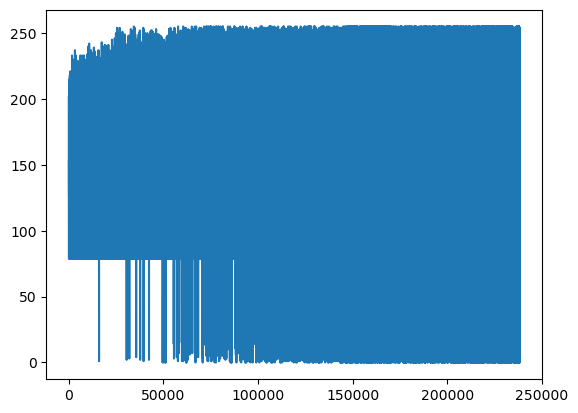

In [6]:
sxr1 = data['SXR1'].astype(float)
plt.plot(sxr1)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

hxr         = data['HXR'].astype(float)
hxr11States = data['hxr11States']
flips       = data['flips']

# Each packet contributes N_SEGMENTS (50) decoded integer samples.
# Repeat each packet's relay state 50 times so both subplots share the same x-axis.
SAMPLES_PER_PACKET = N_SEGMENTS  # 50 — one decoded integer per segment
hxr11_expanded = np.repeat(hxr11States, SAMPLES_PER_PACKET).astype(float)

flip_sample_positions = [f['packet'] * SAMPLES_PER_PACKET for f in flips]
flip_directions       = [f['direction'] for f in flips]

fig, (ax_hxr, ax_state) = plt.subplots(
    2, 1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_hxr.plot(hxr, linewidth=0.4, color='steelblue')
ax_hxr.set_ylabel('HXR (24-bit ADC counts)')
ax_hxr.set_title('HXR Data with HXR11 Relay Flip Events')

ax_state.plot(hxr11_expanded, linewidth=0.8, color='darkorange', drawstyle='steps-post')
ax_state.set_ylabel('HXR11 State')
ax_state.set_yticks([0, 1])
ax_state.set_yticklabels(['OFF', 'ON'])
ax_state.set_xlabel('Sample index (50 samples per packet)')

for pos, direction in zip(flip_sample_positions, flip_directions):
    color = 'green' if direction.endswith('ON') else 'red'
    ax_hxr.axvline(x=pos, color=color, linestyle='--', linewidth=1.0, alpha=0.8)
    ax_state.axvline(x=pos, color=color, linestyle='--', linewidth=1.0, alpha=0.8)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linestyle='--', label='OFF→ON flip'),
    Line2D([0], [0], color='red',   linestyle='--', label='ON→OFF flip'),
]
ax_hxr.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nFlip events ({len(flips)} total):")
for f in flips:
    print(f"  Packet {f['packet']:4d}  (sample ~{f['packet']*SAMPLES_PER_PACKET:7d})  {f['direction']}")